# 05 - Plotting


In [1]:
# Ensure local package import when running directly from examples/.
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import nstk
import astropy.units as u
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from shapely.geometry import box, mapping

nstk.initialize(offline=True)

from nstk.coverage import CoverageTargets, CoverageTimeline, IntervalCoverage, LatitudeLongitudeSampler
from nstk.plotting import GeoMap, MapView, available_map_styles, get_map_style, plot_orbits
from nstk.propagation import build_two_body_walker_constellation

np.set_printoptions(precision=3, suppress=True)


## 1. Build Small Demo Inputs

We reuse a small set of demo objects throughout the notebook:
- a six-satellite Walker-style constellation
- a regional coverage field over the western Pacific
- a few city points and one simple route
- a synthetic gridded scalar/vector field for raster and contour examples

In [3]:
epoch = Time("2026-01-01T00:00:00", scale="utc")

orbits = build_two_body_walker_constellation(
    epoch=epoch,
    a=6_878_000.0,
    e=0.001,
    i=np.deg2rad(53.0),
    raan=0.0,
    argp=0.0,
    anomaly=0.0,
    anomaly_type="mean",
    inertial_frame="gcrf",
    total_satellites=6,
    num_planes=3,
    phasing=1,
)

timeline = CoverageTimeline.absolute(
    epoch + np.arange(0.0, 6.0 * 3600.0 + 600.0, 600.0) * u.s,
    label="6 hour plotting demo",
)

targets = CoverageTargets.region_bbox(
    west_deg=115.0,
    east_deg=150.0,
    south_deg=5.0,
    north_deg=45.0,
    sampler=LatitudeLongitudeSampler(nlats=21, nlons=29),
)

coverage = IntervalCoverage.from_orbits(
    orbits=orbits,
    timeline=timeline,
    targets=targets,
)

field = coverage.access_duration(min_assets=1, normalize="day", unit="hours")
field_two_asset = coverage.access_duration(min_assets=2, normalize="day", unit="hours")

route_lon = np.array([139.760, 121.565, 120.984], dtype=np.float64)
route_lat = np.array([35.680, 25.033, 14.600], dtype=np.float64)

sites = {
    "name": np.array(["Tokyo", "Taipei", "Manila", "Osaka"], dtype=object),
    "lon": np.array([139.760, 121.565, 120.984, 135.502], dtype=np.float64),
    "lat": np.array([35.680, 25.033, 14.600, 34.694], dtype=np.float64),
    "score": np.array([0.95, 0.72, 0.61, 0.83], dtype=np.float64),
}

grid_lon = np.linspace(115.0, 150.0, 25)
grid_lat = np.linspace(5.0, 45.0, 21)
grid_lon_2d, grid_lat_2d = np.meshgrid(grid_lon, grid_lat)
scalar_grid = np.cos(np.deg2rad(grid_lat_2d - 20.0)) * np.sin(np.deg2rad(grid_lon_2d - 125.0))
u_grid = np.cos(np.deg2rad(grid_lat_2d))
v_grid = np.sin(np.deg2rad(grid_lon_2d - 125.0))

{
    "n_orbits": len(orbits),
    "timeline_samples": timeline.seconds.size,
    "n_targets": targets.n_targets,
    "available_styles": available_map_styles(),
}


{'n_orbits': 6,
 'timeline_samples': 37,
 'n_targets': 609,
 'available_styles': ('dark',
  'dark_detailed',
  'dark_detailed_no_grid',
  'dark_no_grid',
  'dark_raster',
  'dark_raster_no_grid',
  'light',
  'light_detailed',
  'light_detailed_no_grid',
  'light_no_grid',
  'light_raster',
  'light_raster_no_grid')}

## 2. Quick Start With `GeoMap`

The simplest path is to create a `GeoMap`, add a few layers, and let `extent="auto"` fit the view.

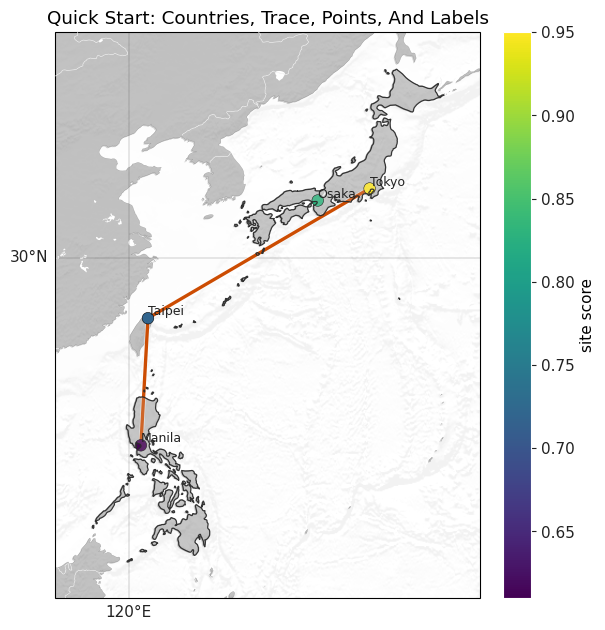

In [4]:
quick_map = GeoMap(style="light_detailed", extent="auto", pad_deg=3.0)
quick_map.add_countries(
    ["Japan", "Philippines"],
    facecolor="#d9d9d9",
    fill_alpha=0.18,
    edgecolor="#2b2b2b",
    linewidth=0.9,
    resolution="50m",
)
quick_map.add_feature(cfeature.BORDERS, edgecolor="#888888", linewidth=0.25, alpha=0.45)
quick_map.add_trace(route_lon, route_lat, color="#cc4c02", linewidth=2.4, glow=True)
quick_map.add_points(
    sites["lon"],
    sites["lat"],
    values=sites["score"],
    size=70.0,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.4,
    colorbar=True,
    colorbar_label="site score",
)
quick_map.add_labels(
    sites["lon"],
    sites["lat"],
    sites["name"],
    fontsize=9,
    ha="left",
    va="bottom",
)
quick_map.set_title("Quick Start: Countries, Trace, Points, And Labels")
plt.show()

## 3. Reusable `MapStyle` And `MapView`

`MapStyle` controls the visual treatment.
`MapView` controls projection, extent, and layout.

The nice part is that both can be reused across plots.

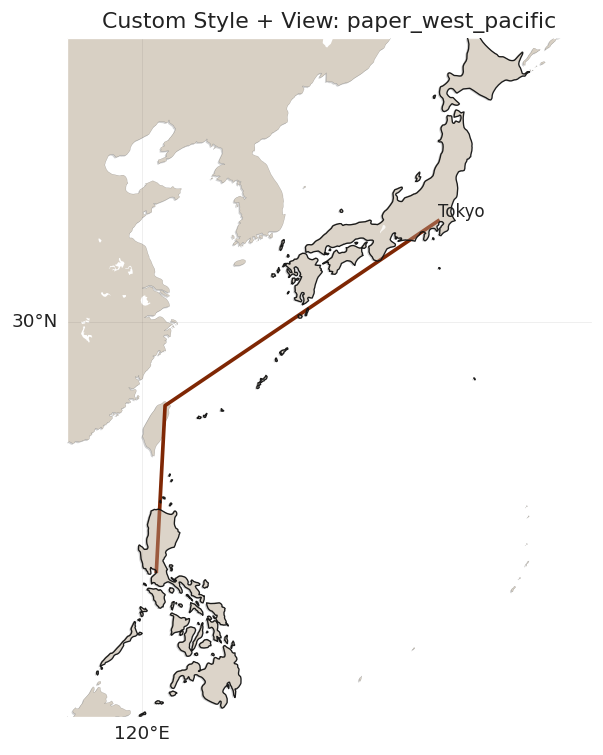

In [5]:
paper = (
    get_map_style("light_detailed")
    .with_land(facecolor="#d8d0c4")
    .with_grid(alpha=0.14, draw_labels=False)
    .with_borders(enabled=False)
    .renamed("paper_west_pacific")
    .register(overwrite=True)
)

west_pacific = (
    MapView()
    .with_projection(name="Mercator")
    .with_extent((115.0, 150.0, 5.0, 45.0), global_map=False)
)

style_map = GeoMap(style=paper, view=west_pacific)
style_map.add_countries(["Japan", "Philippines"], facecolor="#e8e1d7", fill_alpha=0.28, resolution="50m")
style_map.add_trace(route_lon, route_lat, color="#7f2704", linewidth=2.2)
style_map.add_text(139.760, 35.680, "Tokyo", fontsize=10, ha="left", va="bottom")
style_map.set_title(f"Custom Style + View: {paper.name}")
plt.show()

## 4. Generic `add(...)`, Countries, GeoJSON, And Layer Handles

The generic dispatcher accepts several object types directly.
This is the easiest way to mix NSTK objects with arbitrary geographic data.

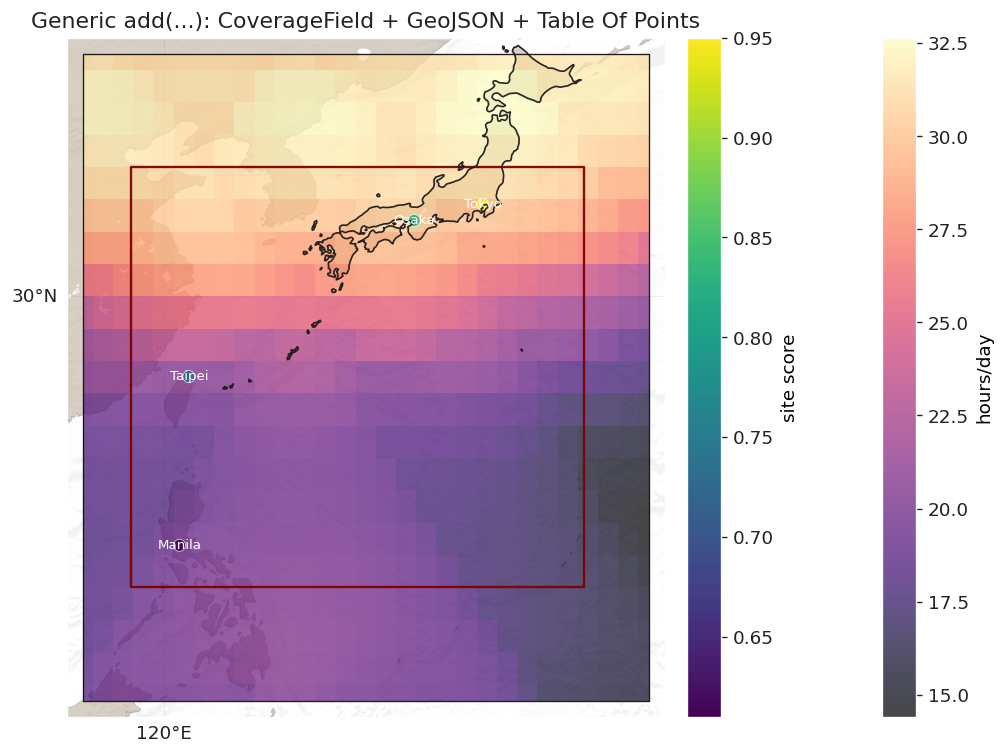

In [6]:
mixed_map = GeoMap(style=paper, extent="auto", pad_deg=1.5)

field_layer = mixed_map.add(field, cmap="magma", alpha=0.72)
box_layer = mixed_map.add(
    mapping(box(118.0, 12.0, 146.0, 38.0)),
    facecolor="none",
    edgecolor="#7f0000",
    linewidth=1.4,
)
city_layer = mixed_map.add(
    sites,
    kind="points",
    x="lon",
    y="lat",
    values="score",
    size=52.0,
    edgecolors="white",
    linewidths=0.4,
    colorbar=True,
    colorbar_label="site score",
)
mixed_map.add_country("Japan", facecolor="none", edgecolor="#1b1b1b", linewidth=1.0, resolution="50m")
mixed_map.add_labels(sites["lon"], sites["lat"], sites["name"], fontsize=8, color="white")

city_layer.set_alpha(0.9)
mixed_map.fit(layers=[field_layer, box_layer], pad_deg=1.0)
mixed_map.set_title("Generic add(...): CoverageField + GeoJSON + Table Of Points")
plt.show()

## 5. Gridded Scalar And Vector Layers

`GeoMap` also supports generic gridded data.
Here we combine a raster surface, contour lines, quiver vectors, and a text annotation.

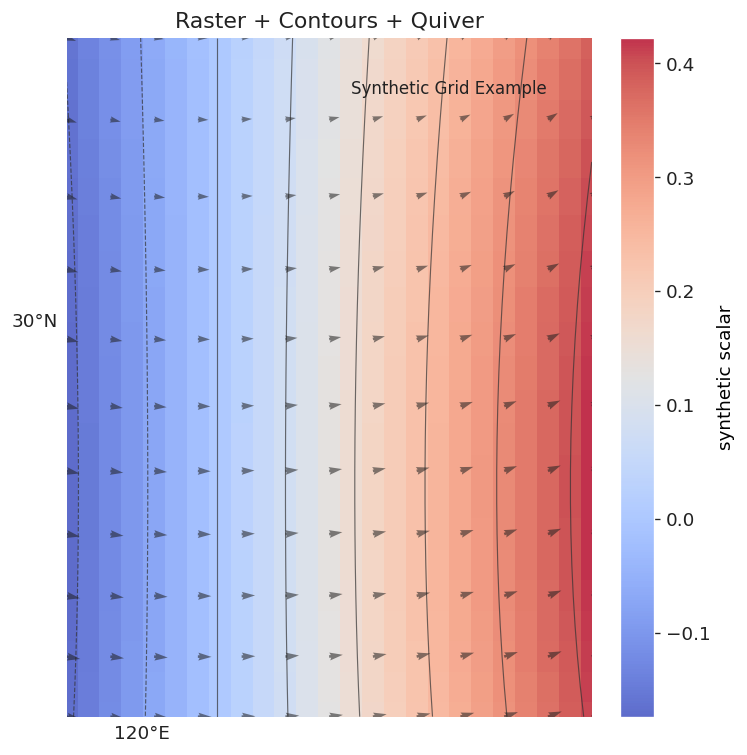

In [7]:
grid_map = GeoMap(style="light_raster_no_grid", view=west_pacific)
grid_map.add_raster(
    scalar_grid,
    lon_deg=grid_lon,
    lat_deg=grid_lat,
    cmap="coolwarm",
    alpha=0.82,
    colorbar=True,
    colorbar_label="synthetic scalar",
)
grid_map.add_contours(
    scalar_grid,
    lon_deg=grid_lon,
    lat_deg=grid_lat,
    levels=8,
    colors="#333333",
    linewidths=0.7,
    alpha=0.7,
)
grid_map.add_quiver(
    grid_lon_2d[::2, ::2],
    grid_lat_2d[::2, ::2],
    u_grid[::2, ::2],
    v_grid[::2, ::2],
    color="#1f1f1f",
    alpha=0.55,
    scale=38.0,
)
grid_map.add_text(147.0, 43.0, "Synthetic Grid Example", fontsize=10, ha="right", va="top")
grid_map.set_title("Raster + Contours + Quiver")
plt.show()

## 6. Coverage Results Plot Themselves

Coverage result objects now plot directly onto the shared map system.
For common usage, this is usually the shortest path.

In [8]:
field.summary()

{'min': 14.412274678548178,
 'max': 32.645365397135414,
 'mean': 23.507234818699192,
 'std': 5.735326041226733}

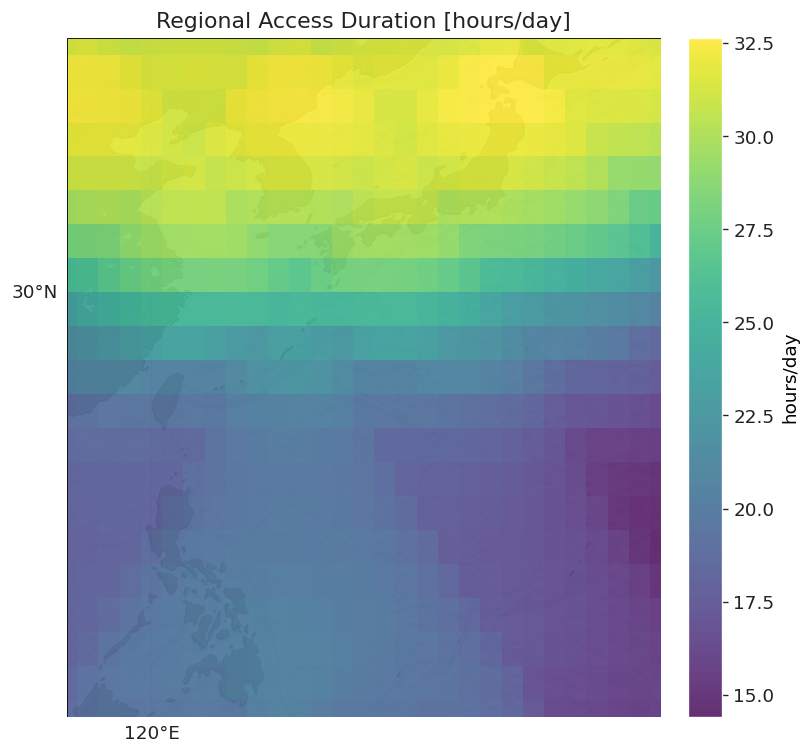

In [9]:
field.plot(
    style=paper,
    title="Regional Access Duration [hours/day]",
    cmap="viridis",
)
plt.show()

## 7. Comparing Multiple Coverage Fields

`CoverageField` is now the only map-style coverage result type.
If you want to compare different metric settings, compute each field separately and keep the style, view, and color scale consistent across the plots.

Here we compare access duration for `min_assets=1` and `min_assets=2`.
The important part is not a special container object. It is just that both plots reuse the same `MapStyle`, `MapView`, `cmap`, `vmin`, and `vmax` so the colors mean the same thing in both figures.


In [10]:
shared_vmin = float(min(np.nanmin(field.values), np.nanmin(field_two_asset.values)))
shared_vmax = float(max(np.nanmax(field.values), np.nanmax(field_two_asset.values)))

{
    "shared_color_scale": (shared_vmin, shared_vmax),
    "min_assets_1_summary": field.summary(),
    "min_assets_2_summary": field_two_asset.summary(),
}


{'shared_color_scale': (0.0, 32.645365397135414),
 'min_assets_1_summary': {'min': 14.412274678548178,
  'max': 32.645365397135414,
  'mean': 23.507234818699192,
  'std': 5.735326041226733},
 'min_assets_2_summary': {'min': 0.0,
  'max': 6.668830871582031,
  'mean': 3.0838074415318615,
  'std': 2.2470802818237487}}

This is the manual comparison pattern after the API simplification: compute two fields, then plot each one explicitly.
That makes the control flow obvious and keeps the coverage result model focused on a single map field at a time.


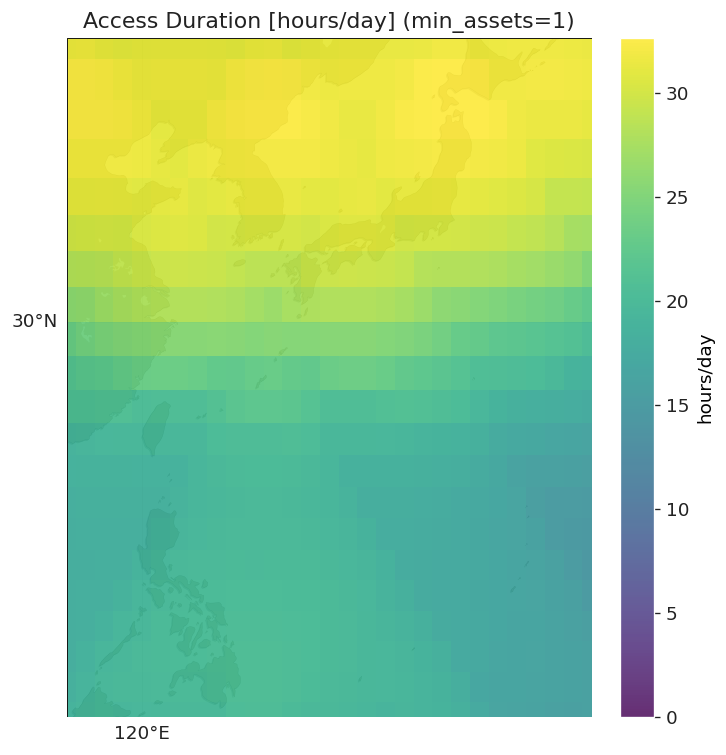

In [11]:
field.plot(
    style=paper,
    view=west_pacific,
    title="Access Duration [hours/day] (min_assets=1)",
    cmap="viridis",
    vmin=shared_vmin,
    vmax=shared_vmax,
)
plt.show()


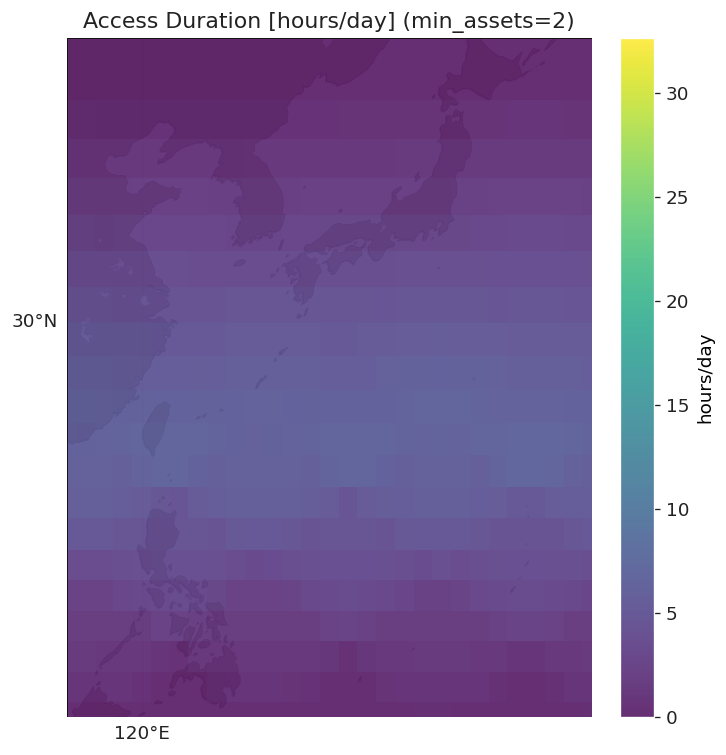

In [12]:
field_two_asset.plot(
    style=paper,
    view=west_pacific,
    title="Access Duration [hours/day] (min_assets=2)",
    cmap="viridis",
    vmin=shared_vmin,
    vmax=shared_vmax,
)
plt.show()


## 8. Orbit Plotting On The Same Style/View System

2D orbit plotting now uses the shared map backend too, so the same `MapStyle` and `MapView` objects work there.

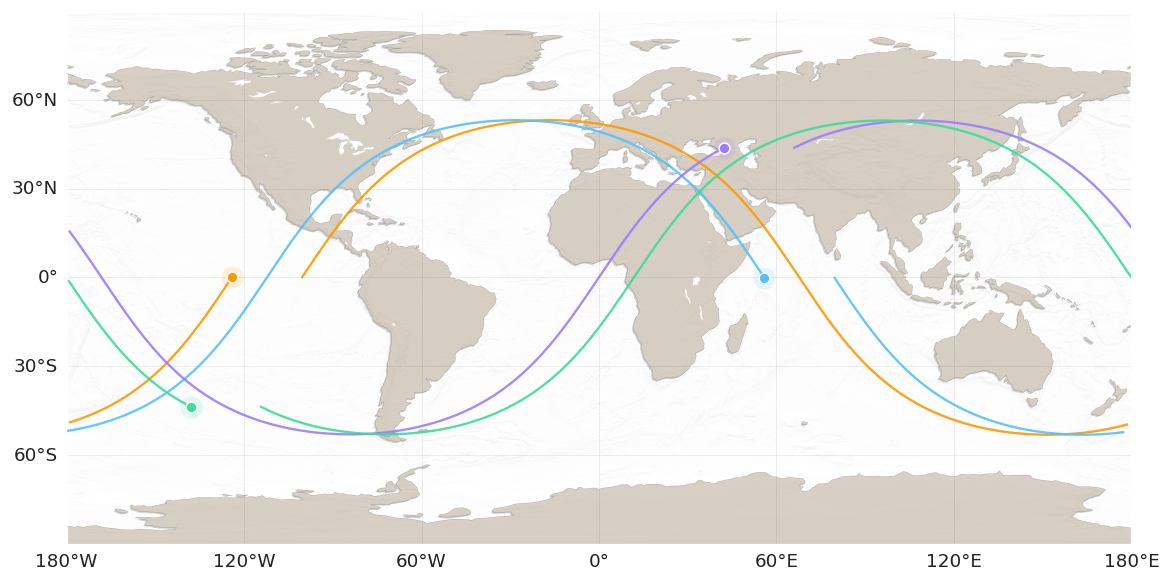

In [13]:
plot_orbits(
    orbits[:4],
    view="2d",
    map_style=paper,
    samples=180,
    line_width=1.4,
    show=False,
)
plt.show()

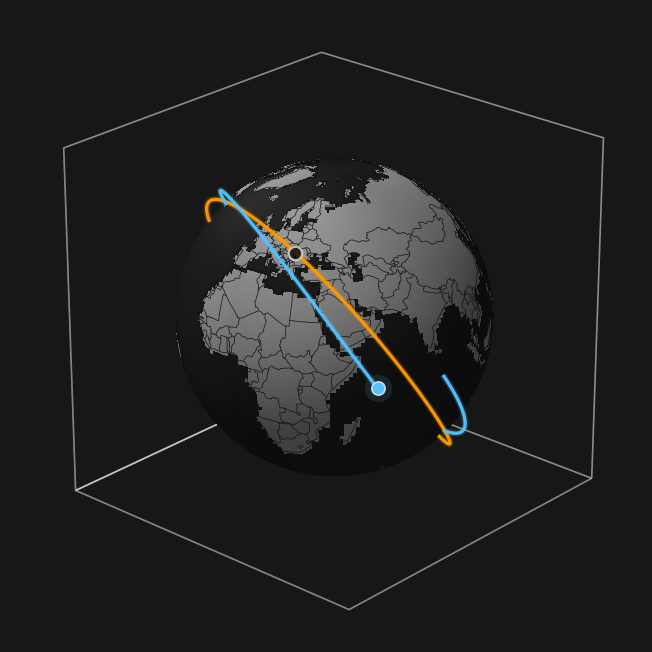

In [14]:
plot_orbits(
    orbits[:2],
    view="3d",
    samples=180,
    line_width=2.0,
    marker_size=8.0,
    show=False,
)
plt.show()

## 9. Expert Path: Compile To `MapConfig`

Most users should stay with `style=` and `view=`.
If you ever need the exact renderer config, you can still compile them down to `MapConfig` and pass `map_cfg=` explicitly.

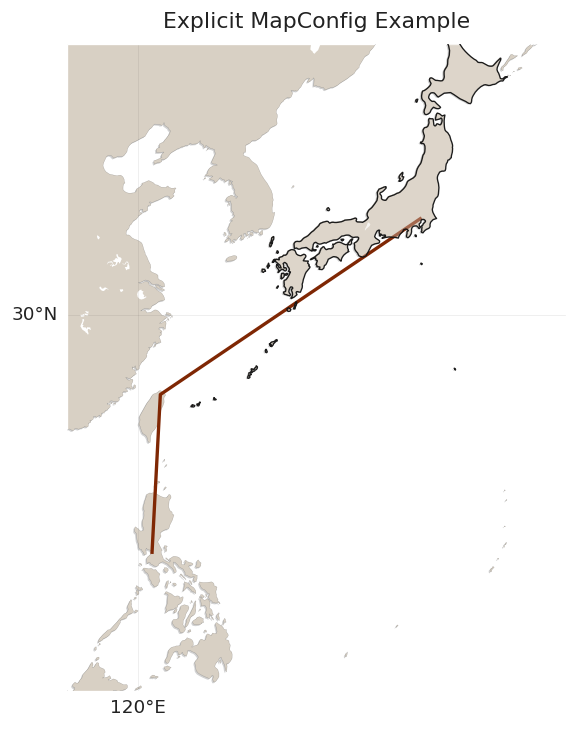

In [15]:
compiled_cfg = paper.to_map_config(view=west_pacific.with_title("Explicit MapConfig Example"))

expert_map = GeoMap(map_cfg=compiled_cfg)
expert_map.add_country("Japan", facecolor="#e8e1d7", fill_alpha=0.35, resolution="50m")
expert_map.add_trace(route_lon, route_lat, color="#7f2704", linewidth=2.0)
plt.show()

That is the full plotting stack in one place:
- use `GeoMap` when you want to compose layers directly
- use `MapStyle` and `MapView` when you want reusable defaults
- use `field.plot(...)` and `plot_orbits(...)` when you want the shortest high-level path
- compare multiple coverage cases by computing separate `CoverageField` objects and reusing the same style/view/color scale
- drop to `map_cfg=` only when you need exact renderer-level control
